In [1]:
import pandas as pd
import wrds 
import numpy as np
import tidyfinance as tf
import sqlite3

In [36]:
# Read the CSV file
characteristics = pd.read_csv("datashare.csv")

# Rename 'DATE' column to 'month'
characteristics.rename(columns={'DATE': 'month'}, inplace=True)

# Convert 'month' to datetime and floor to the month (i.e., set day to the first of the month)
characteristics['month'] = pd.to_datetime(characteristics['month'], format='%Y%m%d')

characteristics['month'] = characteristics['month'].dt.to_period('M').dt.to_timestamp()

# Rename all columns except 'permno', 'month', and 'sic2' by adding a prefix 'characteristic_'
cols_to_prefix = {col: f"characteristic_{col}" for col in characteristics.columns 
                  if col not in ['permno', 'month', 'sic2']}
characteristics.rename(columns=cols_to_prefix, inplace=True)

# Drop rows with NA in 'sic2'
characteristics.dropna(subset=['sic2'], inplace=True)

# Convert 'sic2' to a categorical type
characteristics['sic2'] = characteristics['sic2'].astype('category')

# Display the first few rows to verify changes (optional)
print(characteristics.head())

   permno      month  characteristic_mvel1  characteristic_beta  \
0   10006 1957-01-01             82249.000             1.122846   
6   10102 1957-01-01            186193.500             1.445027   
7   10137 1957-01-01            225984.000             0.585546   
8   10145 1957-01-01            962994.375             1.132210   
9   10153 1957-01-01            279846.875             1.173314   

   characteristic_betasq  characteristic_chmom  characteristic_dolvol  \
0               1.260784              0.047180               9.569953   
6               2.088104             -0.058910              10.375318   
7               0.342864             -0.090805               8.887653   
8               1.281900             -0.084218              10.850652   
9               1.376666             -0.008426              10.547950   

   characteristic_idiovol  characteristic_indmom  characteristic_mom1m  ...  \
0                0.025742               0.046433              0.044843  ...   


In [37]:
def rank_transform(x):
    """
    Transform a pandas Series x by ranking its values and scaling them to [-1, 1].
    Missing values are preserved.
    """
    # Compute ranks (pandas rank() returns NaN for missing values)
    rank_x = x.rank(method='average')
    
    # Compute the number of non-missing values
    non_missing = x.dropna()
    max_rank = non_missing.shape[0]
    min_rank = 1
    
    # If there are no non-missing values, return a Series of NA
    if max_rank == 0:
        return pd.Series([pd.NA] * len(x), index=x.index)
    else:
        # Scale the ranks to [-1, 1]
        return 2 * ((rank_x - min_rank) / (max_rank - min_rank) - 0.5)

# Identify columns that contain "characteristic"
cols = [col for col in characteristics.columns if "characteristic" in col]

# Group by 'month' and apply the rank_transform function across the identified columns
characteristics[cols] = characteristics.groupby('month')[cols].transform(rank_transform)


# Optional: Display the first few rows to verify the transformation
print(characteristics.head())

/var/folders/vp/vwh08pz54dg6rld06q0l1d0w0000gn/T/ipykernel_71406/3050484304.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  characteristics[cols] = characteristics.groupby('month')[cols].transform(rank_transform)


   permno      month  characteristic_mvel1  characteristic_beta  \
0   10006 1957-01-01             -0.101215             0.178862   
6   10102 1957-01-01              0.319838             0.686992   
7   10137 1957-01-01              0.400810            -0.577236   
8   10145 1957-01-01              0.890688             0.211382   
9   10153 1957-01-01              0.522267             0.280488   

   characteristic_betasq  characteristic_chmom  characteristic_dolvol  \
0               0.178862              0.390244               0.276423   
6               0.686992             -0.162602               0.630081   
7              -0.577236             -0.382114              -0.119919   
8               0.211382             -0.341463               0.792683   
9               0.280488              0.109756               0.691057   

   characteristic_idiovol  characteristic_indmom  characteristic_mom1m  ...  \
0               -0.052846                    0.0              0.326572  ...   


In [38]:
# Identify columns that contain "characteristic"
cols = [col for col in characteristics.columns if "characteristic" in col]

# Group by 'month' and replace NA values in each characteristic column with the median (ignoring NA) for that group
characteristics[cols] = characteristics.groupby('month')[cols].transform(lambda x: x.fillna(x.median(skipna=True)))

# Replace any remaining NAs in these columns with 0
characteristics[cols] = characteristics[cols].fillna(0)

# Optional: Check the result
print(characteristics.head())

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  

   permno      month  characteristic_mvel1  characteristic_beta  \
0   10006 1957-01-01             -0.101215             0.178862   
6   10102 1957-01-01              0.319838             0.686992   
7   10137 1957-01-01              0.400810            -0.577236   
8   10145 1957-01-01              0.890688             0.211382   
9   10153 1957-01-01              0.522267             0.280488   

   characteristic_betasq  characteristic_chmom  characteristic_dolvol  \
0               0.178862              0.390244               0.276423   
6               0.686992             -0.162602               0.630081   
7              -0.577236             -0.382114              -0.119919   
8               0.211382             -0.341463               0.792683   
9               0.280488              0.109756               0.691057   

   characteristic_idiovol  characteristic_indmom  characteristic_mom1m  ...  \
0               -0.052846                    0.0              0.326572  ...   


In [39]:
db = sqlite3.connect('data.db')

# tf.set_wrds_credentials()

# crsp_monthly = tf.download_data(
#   domain="wrds",
#   dataset="crsp_monthly",
#   start_date='1957-01-01',
#   end_date='2021-12-31'
# )

# crsp_monthly = (crsp_monthly
#   .dropna(subset=["ret_excess", "mktcap", "mktcap_lag"])
# )

# (crsp_monthly
#   .to_sql(name="crsp_monthly", 
#           con=db, 
#           if_exists="replace",
#           index=False)
# )

In [40]:
df_macro_pred = tf.download_data(
  domain="macro_predictors",
  dataset="monthly",
  start_date='1957-01-01', 
  end_date='2021-12-31'
)

df_macro_pred.to_sql(
  name="macro_predictors",
  con=db, 
  if_exists="replace",
  index=False
)



780

In [45]:
from pandas.tseries.offsets import DateOffset

crsp_monthly = pd.read_sql_query(
    "SELECT date, permno, mktcap_lag, ret_excess FROM crsp_monthly", 
    db
)
crsp_monthly['month'] = pd.to_datetime(crsp_monthly['date'])


# Read the macro_predictors table
macro_predictors = pd.read_sql_query(
    "SELECT date, dp, ep, bm, ntis, tbl, tms, dfy, svar FROM macro_predictors", 
    db
)
macro_predictors['month'] = pd.to_datetime(macro_predictors['date'])


# Rename all columns except 'month' with the prefix "macro_"
macro_predictors = macro_predictors.rename(
    columns=lambda x: f"macro_{x}" if x != "month" else x
)

# ---------------------------
# 2. Shift macro predictors by one month and merge
# ---------------------------
# Create a shifted copy with month increased by one month
macro_shifted = macro_predictors.copy()
macro_shifted['month'] = macro_shifted['month'] + DateOffset(months=1)


# Left join on 'month': start with the original 'month' column then join the shifted predictors
macro_predictors_final = macro_predictors[['month']].merge(
    macro_shifted, on='month', how='left'
)


# ---------------------------
# 3. Merge with Characteristics Data
# ---------------------------
# Ensure characteristics 'month' column is datetime
characteristics['month'] = pd.to_datetime(characteristics['month'])
characteristics

# Merge characteristics with crsp_monthly on ['month', 'permno']
df = characteristics.merge(crsp_monthly, on=['month', 'permno'], how='inner')

# Merge with the macro predictors on 'month'
df = df.merge(macro_predictors_final, on='month', how='inner')

# Sort the DataFrame by month and permno
df.sort_values(['month', 'permno'], inplace=True)


# Create a macro_intercept column equal to 1
df['macro_intercept'] = 1

# ---------------------------
# 4. Select Final Columns
# ---------------------------
# Select permno, month, ret_excess, mktcap_lag, sic2,
# and any columns containing "macro" or "characteristic"
selected_cols = ['permno', 'month', 'ret_excess', 'mktcap_lag', 'sic2']
selected_cols += [col for col in df.columns if 'macro' in col or 'characteristic' in col]
df = df[selected_cols]

# Optional: Display the first few rows
df.head()

,permno,month,ret_excess,mktcap_lag,sic2,characteristic_mvel1,characteristic_beta,characteristic_betasq,characteristic_chmom,characteristic_dolvol,...,macro_date,macro_dp,macro_ep,macro_bm,macro_ntis,macro_tbl,macro_tms,macro_dfy,macro_svar,macro_intercept
0,10006,1957-02-01,-0.000417,87.54400,37.0,-0.056680,0.126016,0.126016,0.670732,0.221095,...,1957-01-01 00:00:00,-3.248434,-2.574677,0.567243,0.027992,0.0311,0.0017,0.0072,0.000902,1
1,10102,1957-02-01,0.038594,183.42825,28.0,0.327935,0.695122,0.695122,-0.325203,0.488844,...,1957-01-01 00:00:00,-3.248434,-2.574677,0.567243,0.027992,0.0311,0.0017,0.0072,0.000902,1
2,10137,1957-02-01,-0.012659,228.09600,49.0,0.433198,-0.532520,-0.532520,0.252033,-0.152130,...,1957-01-01 00:00:00,-3.248434,-2.574677,0.567243,0.027992,0.0311,0.0017,0.0072,0.000902,1
3,10145,1957-02-01,-0.037752,907.22250,99.0,0.890688,0.243902,0.243902,-0.252033,0.870183,...,1957-01-01 00:00:00,-3.248434,-2.574677,0.567243,0.027992,0.0311,0.0017,0.0072,0.000902,1
4,10153,1957-02-01,-0.002400,270.68825,13.0,0.518219,0.284553,0.284553,-0.199187,0.813387,...,1957-01-01 00:00:00,-3.248434,-2.574677,0.567243,0.027992,0.0311,0.0017,0.0072,0.000902,1


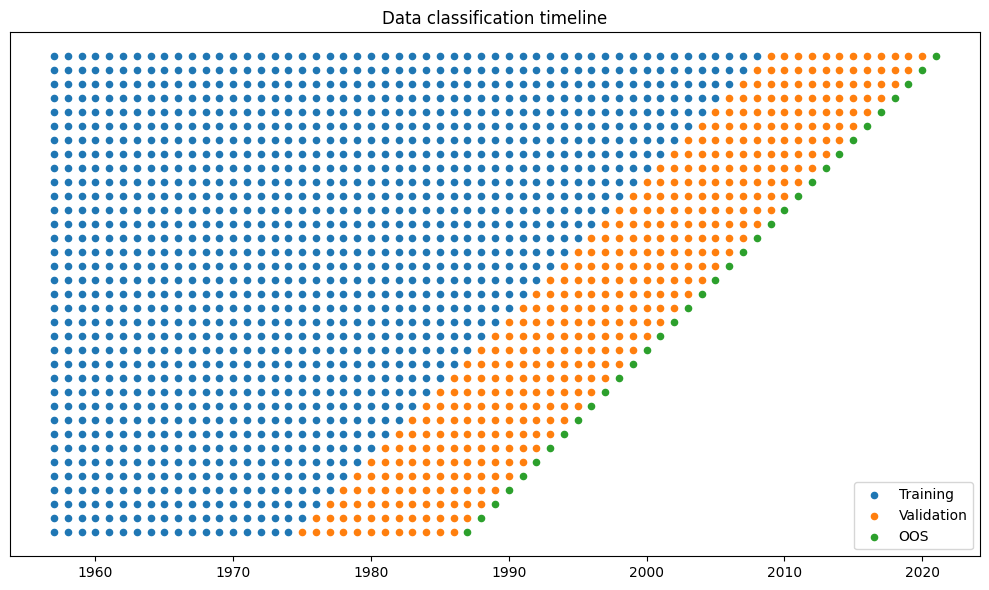

In [46]:
import matplotlib.pyplot as plt
# Set the validation length
validation_length = 12

# Create a DataFrame for estimation periods
oos_years = range(1987, 2022)  # 1987 to 2021 inclusive
estimation_periods = pd.DataFrame({
    'oos_year': list(oos_years)
})
estimation_periods['validation_end'] = estimation_periods['oos_year'] - 1
estimation_periods['validation_start'] = estimation_periods['oos_year'] - validation_length
estimation_periods['training_start'] = 1957
estimation_periods['training_end'] = estimation_periods['validation_start'] - 1

# Select only the columns containing "training" and the other needed columns
cols = [col for col in estimation_periods.columns if 'training' in col] + ['validation_start', 'validation_end', 'oos_year']
estimation_periods = estimation_periods[cols]

# Build the visualization data by iterating over each estimation period
rows = []
for _, row in estimation_periods.iterrows():
    # Loop through each year from 1957 to 2021
    for year in range(1957, 2022):
        classification = None
        # Check conditions for classification as in the R code
        if row['training_start'] <= year <= row['training_end']:
            classification = "Training"
        elif row['validation_start'] <= year <= row['validation_end']:
            classification = "Validation"
        elif year == row['oos_year']:
            classification = "OOS"
        
        # Only add rows with a non-null classification
        if classification is not None:
            rows.append({
                'year': year,
                'oos_year': row['oos_year'],
                'classification': classification
            })

# Create the DataFrame and drop any rows with missing values (if any)
visualization_data = pd.DataFrame(rows)

# Plotting the results using Matplotlib
fig, ax = plt.subplots(figsize=(10, 6))

# Plot each classification separately to assign distinct colors
for cls in visualization_data['classification'].unique():
    subset = visualization_data[visualization_data['classification'] == cls]
    ax.scatter(subset['year'], subset['oos_year'], label=cls, s=20)  # s controls marker size

# Customize the plot to mirror the ggplot style
ax.set_title("Data classification timeline")
ax.set_xlabel("")
ax.set_ylabel("")

# Remove y-axis ticks and labels
ax.set_yticks([])
ax.tick_params(axis='y', which='both', length=0)

# Remove legend title
ax.legend(title="")

plt.tight_layout()
plt.show()

In [55]:
import multiprocessing
from sklearn.ensemble import RandomForestRegressor

# Determine the number of threads to use (all but one physical core)
n_jobs = max(multiprocessing.cpu_count() - 1, 1)

# Define the random forest model with fixed number of trees and parameters to tune
rf_model = RandomForestRegressor(
    n_estimators=300,
    n_jobs=n_jobs,
    random_state=42  # set for reproducibility
)

# Create a parameter grid for tuning. Here:
# - 'max_features' corresponds to mtry,
# - 'min_samples_leaf' corresponds to min_n.
rf_grid = {
    'model__max_features': [3, 5, 10, 20, 30, 50],
    'model__min_samples_leaf': [5000, 10000]
}

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

print(df)
if 'macro_data' in df.columns:
    df = df.drop(columns=['macro_date'])
df['year'] = df['month'].dt.year
# Assume characteristics_prepared is your prepared DataFrame.
# For example, you might collect a sample using:
data_sample_final = df.head().copy()


# Define the ID columns and target.
id_cols = ['permno', 'month', 'mktcap_lag', 'year']
target = 'ret_excess'

# Define the feature columns:
# In the formula ret_excess ~ 0 + ., we drop the ID columns and the target from predictors.
feature_cols = [col for col in data_sample_final.columns if col not in id_cols + [target]]

# Build a preprocessor that simply passes through the feature columns.
preprocessor = ColumnTransformer(
    transformers=[('features', 'passthrough', feature_cols)],
    remainder='drop'
)

# Now build the overall pipeline (workflow) by combining the preprocessor with your rf_model.
ml_workflow = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf_model)  # rf_model defined earlier, e.g., as a RandomForestRegressor instance.
])

         permno      month  ret_excess    mktcap_lag  sic2  \
0         10006 1957-02-01   -0.000417  8.754400e+01  37.0   
1         10102 1957-02-01    0.038594  1.834282e+02  28.0   
2         10137 1957-02-01   -0.012659  2.280960e+02  49.0   
3         10145 1957-02-01   -0.037752  9.072225e+02  99.0   
4         10153 1957-02-01   -0.002400  2.706882e+02  13.0   
...         ...        ...         ...           ...   ...   
3063944   93397 2021-12-01    0.030918  2.585547e+02   1.0   
3063945   93423 2021-12-01    0.164242  3.144398e+03  79.0   
3063946   93426 2021-12-01    0.081170  4.326610e+02  36.0   
3063947   93434 2021-12-01   -0.065169  1.130478e+02   1.0   
3063948   93436 2021-12-01   -0.076955  1.149642e+06  37.0   

         characteristic_mvel1  characteristic_beta  characteristic_betasq  \
0                   -0.056680             0.126016               0.126016   
1                    0.327935             0.695122               0.695122   
2                    0.4

In [52]:
# Assume j is the current iteration index (starting at 1)
j = 1  # For full replication, loop until len(estimation_periods)
# Select the jth row of estimation_periods
split_dates = estimation_periods.iloc[j - 1]  # j-1 because Python is 0-indexed

# Filter training data: use rows where the year of 'month' is less than training_end
train = df[
    df['year'] < split_dates['training_end']
].copy()

print(split_dates['validation_start'])
print(split_dates['validation_end'])
# Filter validation data: use rows where the year of 'month' is between validation_start and validation_end (inclusive)
validation = df[
    (df['year'] >= split_dates['validation_start']) &
    (df['year'] <= split_dates['validation_end'])
].copy()

# Create a data split dictionary similar to make_splits in R
data_split = {"train": train, "assessment": validation}

# Mimic manual_rset by putting the split into a list with an identifier
folds = {"split": [data_split]}

# Optionally, you can print or inspect the splits:
print("Training set shape:", train.shape)
print("Validation set shape:", validation.shape)

1975
1986
Training set shape: (288321, 109)
Validation set shape: (639252, 109)


In [56]:
from sklearn.model_selection import GridSearchCV, PredefinedSplit

# Suppose you already have the training and validation sets from your manual split:
#   - 'train' and 'validation' are DataFrames created earlier.
#   - The target variable is 'ret_excess'.
#   - All predictors needed by ml_workflow are present in both.

# Combine the training and validation sets.
combined = pd.concat([train, validation], ignore_index=True)

# Separate predictors and target.
X = combined.drop(columns=['ret_excess'])
y = combined['ret_excess']

# Create a predefined split:
# For PredefinedSplit, test_fold is an array with the same length as X,
# where a value of -1 indicates a training observation, and any non-negative
# number indicates the test fold. Here, we assign 0 for all validation observations.
train_len = train.shape[0]
validation_len = validation.shape[0]
# First 'train_len' rows are training (-1), and the remaining are validation (0)
test_fold = np.array([-1] * train_len + [0] * validation_len)
ps = PredefinedSplit(test_fold)

# Set up GridSearchCV to tune the parameters:
# - Use the negative RMSE scoring ("neg_root_mean_squared_error")
# - Use all available cores with n_jobs=-1 (similar to multisession with nbrOfWorkers())
grid_search = GridSearchCV(
    estimator=ml_workflow,
    param_grid=rf_grid,
    scoring='neg_root_mean_squared_error',
    cv=ps,
    n_jobs=-1,
    refit=True,
    verbose=1
)

# Fit the grid search to your data.
grid_search.fit(X, y)

# The resulting best model and results are stored in grid_search.
print("Best parameters found:", grid_search.best_params_)
print("Best (negative) RMSE:", grid_search.best_score_)

Fitting 1 folds for each of 12 candidates, totalling 12 fits


KeyboardInterrupt: 